In [185]:
import os
import time
import random
import warnings
from datetime import date

import numpy as np
import pandas as pd
import pyarrow as pa
import pyarrow.parquet as pq
from lxml import etree # type: ignore <- pylance milně hlásí chybu
from pathlib import Path
import time
import sys
import polars as pl
import polars.selectors as cs
import json
import pickle
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import matplotlib.patheffects as path_effects
from ydata_profiling import ProfileReport
import geopandas as gpd


current_dir = Path(__file__).resolve().parent if "__file__" in locals() else Path.cwd()
sys.path.append(str(current_dir.parent))
from utils import *
from schemas import *
from clean import *
from visualisation_utils import *

pl.Config.set_tbl_cols(-1)
os.chdir(r'E:\CVUT_BAP')
SEED=42
PRINT = True

# Načtení dat

In [24]:
df = pl.read_parquet(r'kod\data\extracted\prohlidky_vozidel_stk_a_sme\parquet', schema=prohlidky_schema)
if PRINT: describe(df)

CisloProtokolu,DatumProhlidky,DruhProhlidky,RozsahProhlidky,Prohlidka_OdpovednaOsoba,Prohlidka_Stanice_Cislo,Prohlidka_Stanice_Kraj,Prohlidka_Stanice_ORP,Prohlidka_Stanice_Obec,Prohlidka_Zahajeni,Prohlidka_Ukonceni,AdministrativniOprava_CisloProtokolu,AdministrativniOprava_DatumProhlidky,Vozidlo_Vin,Vozidlo_Druh,Vozidlo_Kategorie,Vozidlo_Provedeni,Vozidlo_Znacka,Vozidlo_ObchodniOznaceni,Vozidlo_TypMotoru,Registrace_DatumPrvni,Registrace_Stat,Registrace_CisloDokladu,Emise_CisloProtokolu,Emise_DatumProhlidky,Emise_StaniceCislo,Emise_Zahajeni,Emise_Ukonceni,Emise_OdpovednaOsoba,Emise_ZakladniPalivo,Emise_AlternativniPalivo,Emise_EmisniSystem,Emise_VyrobceMotoru,Emise_CisloMotoru,Vysledek_Odometr,Vysledek_Poznamka,Vysledek_DatumPristiProhlidky,Vysledek_NalepkaVylepena,Vysledek_Celkovy,TechnickaCast_Pritomno,AdrCast_Pritomno,TskCast_Pritomno,Zavady_A,Zavady_B,Zavady_C
str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,list[str],list[str],list[str]
"""CZ-520406-19-01-0001""","""2019-01-01""","""Pravidelná""",null,"""16835""","""520406""","""Středočeský kraj""","""Kolín""","""Žabonosy""","""2019-01-01T15:21:49.0770000+01…","""2019-01-01T15:40:05.4700000+01…",null,null,"""WV1ZZZ7HZ7H079425""","""NÁKLADNÍ AUTOMOBIL""","""N1""",null,"""VW""","""TRANSPORTER""","""BPC""","""2007-01-03T00:00:00.0000000+01…","""Česká republika""","""UB654181""","""CZ-520406-19-01-0001""","""2019-01-01T15:40:05.4700000+01…","""520406""","""2019-01-01T15:22:33.2900000+01…","""2019-01-01T15:39:51.5500000+01…","""16835""","""Nafta""",null,"""Řízený s OBD""",null,null,"""309068""",null,"""2021-01-01""",null,"""1""","""False""","""False""","""False""",null,null,null


(20106136, 45)


,CisloProtokolu,DatumProhlidky,DruhProhlidky,RozsahProhlidky,Prohlidka_OdpovednaOsoba,Prohlidka_Stanice_Cislo,Prohlidka_Stanice_Kraj,Prohlidka_Stanice_ORP,Prohlidka_Stanice_Obec,Prohlidka_Zahajeni,...,Vysledek_Poznamka,Vysledek_DatumPristiProhlidky,Vysledek_NalepkaVylepena,Vysledek_Celkovy,TechnickaCast_Pritomno,AdrCast_Pritomno,TskCast_Pritomno,Zavady_A,Zavady_B,Zavady_C
0,CZ-520406-19-01-0001,2019-01-01,Pravidelná,None,16835,520406,Středočeský kraj,Kolín,Žabonosy,2019-01-01T15:21:49.0770000+01:00,...,None,2021-01-01,None,1,False,False,False,NaN,NaN,NaN
1,CZ-420930-19-01-0001,2019-01-01,Pravidelná,None,43281,420930,Středočeský kraj,Říčany,Říčany,2019-01-01T14:35:04.4400000+01:00,...,None,2021-01-01,None,1,False,False,False,NaN,NaN,NaN
2,CZ-480811-23-01-0001,2023-01-01,Pravidelná,None,36479,480811,Olomoucký kraj,Přerov,Kojetín,2023-01-01T12:21:49.8570000+01:00,...,None,2025-01-01,None,1,False,False,False,NaN,NaN,NaN
3,CZ-420221-23-01-0004,2023-01-01,Pravidelná,None,44365,420221,Středočeský kraj,Beroun,Bavoryně,2023-01-01T17:25:41.6570000+01:00,...,None,2025-01-01,None,1,False,False,False,NaN,NaN,NaN
4,CZ-420221-23-01-0001,2023-01-01,Pravidelná,None,44365,420221,Středočeský kraj,Beroun,Bavoryně,2023-01-01T16:05:05.4600000+01:00,...,None,2025-01-01,None,1,False,False,False,NaN,NaN,NaN
5,CZ-420221-23-01-0003,2023-01-01,Pravidelná,None,44365,420221,Středočeský kraj,Beroun,Bavoryně,2023-01-01T16:56:47.6530000+01:00,...,None,2025-01-01,None,1,False,False,False,NaN,NaN,NaN
6,CZ-170901-23-01-0001,2023-01-01,Pravidelná,None,89493,170901,Olomoucký kraj,Prostějov,Bedihošť,2023-01-01T19:23:52.2530000+01:00,...,None,2025-01-01,None,1,False,False,False,NaN,NaN,NaN
7,CZ-170901-23-01-0002,2023-01-01,Pravidelná,None,89493,170901,Olomoucký kraj,Prostějov,Bedihošť,2023-01-01T19:40:36.1970000+01:00,...,None,2025-01-01,None,1,False,False,False,NaN,NaN,NaN
8,CZ-520406-24-01-0001,2024-01-01,Pravidelná,None,1308,520406,Středočeský kraj,Kolín,Žabonosy,2024-01-01T11:30:09.4530000+01:00,...,None,2026-01-01,None,1,False,False,False,NaN,NaN,NaN
9,CZ-480811-24-01-0001,2024-01-01,Pravidelná,None,36479,480811,Olomoucký kraj,Přerov,Kojetín,2024-01-01T16:21:48.9530000+01:00,...,None,2026-01-01,None,1,False,False,False,NaN,NaN,NaN


,column,majority_class,majority_cnt,non_null,dtype
0,CisloProtokolu,CZ-261101-25-03-0109,2 / 20 106 136,20 106 136 / 20 106 136,String
1,DatumProhlidky,2025-05-12,18 312 / 20 106 136,20 106 136 / 20 106 136,String
2,DruhProhlidky,Pravidelná,20 043 075 / 20 106 136,20 106 136 / 20 106 136,String
3,RozsahProhlidky,Plný,952 100 / 20 106 136,969 359 / 20 106 136,String
4,Prohlidka_OdpovednaOsoba,35165,68 409 / 20 106 136,20 106 136 / 20 106 136,String
5,Prohlidka_Stanice_Cislo,540514,347 272 / 20 106 136,20 106 136 / 20 106 136,String
6,Prohlidka_Stanice_Kraj,Středočeský kraj,2 958 516 / 20 106 136,20 106 136 / 20 106 136,String
7,Prohlidka_Stanice_ORP,Hlavní město Praha,2 014 789 / 20 106 136,20 106 136 / 20 106 136,String
8,Prohlidka_Stanice_Obec,Praha,2 014 789 / 20 106 136,20 106 136 / 20 106 136,String
9,Prohlidka_Zahajeni,2022-03-17T00:00:00.0000000+01:00,25 / 20 106 136,20 106 136 / 20 106 136,String


# Filtrace vozidel kategorie M1 s palivem Benzín / Nafta

In [25]:
if PRINT:
    display(df['Vozidlo_Kategorie'].value_counts(sort=True))
    display(df['Emise_ZakladniPalivo'].value_counts(sort=True))
    display(df['Emise_AlternativniPalivo'].value_counts(sort=True))

Vozidlo_Kategorie,count
str,u32
"""M1""",16408917
"""N1""",1599865
"""N3""",612147
"""M1G""",501825
"""N2""",330736
…,…
"""L1e-A""",1
"""L7e-B1""",1
"""L6e""",1


Emise_ZakladniPalivo,count
str,u32
"""Nafta""",10577800
"""Benzín""",9425359
"""CNG""",66270
"""Směs""",36014
"""LNG""",430
"""LPG""",263


Emise_AlternativniPalivo,count
str,u32
null,19649414
"""LPG""",423476
"""CNG""",33100
"""LNG""",146


In [26]:
df = df.filter(pl.col('Vozidlo_Kategorie') == 'M1', pl.col('Emise_ZakladniPalivo').is_in(['Benzín', 'Nafta']), pl.col('Emise_AlternativniPalivo').is_null())
if PRINT: schema_description(df)

,column,majority_class,majority_cnt,non_null,dtype
0,CisloProtokolu,CZ-480602-21-10-0029,2 / 15 934 862,15 934 862 / 15 934 862,String
1,DatumProhlidky,2025-05-12,14 774 / 15 934 862,15 934 862 / 15 934 862,String
2,DruhProhlidky,Pravidelná,15 884 707 / 15 934 862,15 934 862 / 15 934 862,String
3,RozsahProhlidky,Plný,735 859 / 15 934 862,748 639 / 15 934 862,String
4,Prohlidka_OdpovednaOsoba,35165,54 577 / 15 934 862,15 934 862 / 15 934 862,String
5,Prohlidka_Stanice_Cislo,540514,250 879 / 15 934 862,15 934 862 / 15 934 862,String
6,Prohlidka_Stanice_Kraj,Středočeský kraj,2 302 762 / 15 934 862,15 934 862 / 15 934 862,String
7,Prohlidka_Stanice_ORP,Hlavní město Praha,1 654 630 / 15 934 862,15 934 862 / 15 934 862,String
8,Prohlidka_Stanice_Obec,Praha,1 654 630 / 15 934 862,15 934 862 / 15 934 862,String
9,Prohlidka_Zahajeni,2025-11-03T08:37:33.2830000+01:00,7 / 15 934 862,15 934 862 / 15 934 862,String


# Přetypování sloupců
Velke mnozstvi zaznamu ma odlisne cislo protokolu pouze z duvodu predchazejicich nul

In [27]:
if PRINT:
    print('Záznamy, kde neodpovídá CisloProtokolu a Emise_CisloProtokolu')
    short_display(df[['CisloProtokolu', 'Emise_CisloProtokolu']].filter(pl.col('CisloProtokolu') != pl.col('Emise_CisloProtokolu')))
df = cast_prohlidka(df)

Záznamy, kde neodpovídá CisloProtokolu a Emise_CisloProtokolu
(748639, 2)


,CisloProtokolu,Emise_CisloProtokolu
0,CZ-3848-19-02-0017,CZ-003848-19-02-0017
1,CZ-3848-19-02-0012,CZ-003848-19-02-0012
2,CZ-3848-19-02-0003,CZ-003848-19-02-0003
3,CZ-3848-19-02-0010,CZ-003848-19-02-0010
4,CZ-3848-19-02-0014,CZ-003848-19-02-0014
5,CZ-3848-19-02-0011,CZ-003848-19-02-0011
6,CZ-3848-19-02-0006,CZ-003848-19-02-0006
7,CZ-3848-19-02-0002,CZ-003848-19-02-0002
8,CZ-3618-21-02-0101,CZ-003618-21-02-0101
9,CZ-3706-21-02-0051,CZ-003706-21-02-0051


# Odstranění nekonzistentních CiselProtokolu
Pouze 3 cisla protokolu nejsou stejna

In [28]:
inconsistent_cislo_protokolu = df[['CisloProtokolu', 'Emise_CisloProtokolu']].filter(pl.col('CisloProtokolu') != pl.col('Emise_CisloProtokolu'))['CisloProtokolu'].to_list()
print(inconsistent_cislo_protokolu)
df = df.filter(~pl.col('CisloProtokolu').is_in(inconsistent_cislo_protokolu))

['CZ-3420-24-02-0512', 'CZ-3420-24-02-0563', 'CZ-3420-24-02-0561']


# Odstranění duplicitních čísel protokolu
Nektere zaznamy se v datove sade vyskytuji vicektrat

In [29]:
if PRINT: short_display(df.filter(pl.col('CisloProtokolu').count().over('CisloProtokolu') > 1).sort('CisloProtokolu'))
df = df.unique()
if PRINT: short_display(df.filter(pl.col('CisloProtokolu').count().over('CisloProtokolu') > 1).sort('CisloProtokolu'))

(1340, 45)


,CisloProtokolu,DatumProhlidky,DruhProhlidky,RozsahProhlidky,Prohlidka_OdpovednaOsoba,Prohlidka_Stanice_Cislo,Prohlidka_Stanice_Kraj,Prohlidka_Stanice_ORP,Prohlidka_Stanice_Obec,Prohlidka_Zahajeni,...,Vysledek_Poznamka,Vysledek_DatumPristiProhlidky,Vysledek_NalepkaVylepena,Vysledek_Celkovy,TechnickaCast_Pritomno,AdrCast_Pritomno,TskCast_Pritomno,Zavady_A,Zavady_B,Zavady_C
0,CZ-110301-25-03-0153,2025-03-26,Pravidelná,None,101929,110301,Hlavní město Praha,Hlavní město Praha,Praha,2025-03-26 13:52:29.103,...,None,2027-03-26,None,1,False,False,False,NaN,NaN,NaN
1,CZ-110301-25-03-0153,2025-03-26,Pravidelná,None,101929,110301,Hlavní město Praha,Hlavní město Praha,Praha,2025-03-26 13:52:29.103,...,None,2027-03-26,None,1,False,False,False,NaN,NaN,NaN
2,CZ-110503-25-03-0726,2025-03-26,Pravidelná,None,82867,110503,Hlavní město Praha,Hlavní město Praha,Praha,2025-03-26 14:03:43.330,...,None,2027-03-26,None,1,False,False,False,NaN,NaN,NaN
3,CZ-110503-25-03-0726,2025-03-26,Pravidelná,None,82867,110503,Hlavní město Praha,Hlavní město Praha,Praha,2025-03-26 14:03:43.330,...,None,2027-03-26,None,1,False,False,False,NaN,NaN,NaN
4,CZ-110802-25-03-0421,2025-03-26,Pravidelná,None,112949,110802,Hlavní město Praha,Hlavní město Praha,Praha,2025-03-26 13:52:44.957,...,None,2027-03-26,None,1,False,False,False,NaN,NaN,NaN
5,CZ-110802-25-03-0421,2025-03-26,Pravidelná,None,112949,110802,Hlavní město Praha,Hlavní město Praha,Praha,2025-03-26 13:52:44.957,...,None,2027-03-26,None,1,False,False,False,NaN,NaN,NaN
6,CZ-110901-21-10-0224,2021-10-12,Pravidelná,None,55017,110901,Hlavní město Praha,Hlavní město Praha,Praha,2021-10-12 07:57:03.890,...,None,2023-10-12,None,1,False,False,False,NaN,NaN,NaN
7,CZ-110901-21-10-0224,2021-10-12,Pravidelná,None,55017,110901,Hlavní město Praha,Hlavní město Praha,Praha,2021-10-12 07:57:03.890,...,None,2023-10-12,None,1,False,False,False,NaN,NaN,NaN
8,CZ-110905-25-03-0145,2025-03-26,Pravidelná,None,912,110905,Hlavní město Praha,Hlavní město Praha,Praha,2025-03-26 13:59:10.907,...,None,2027-03-26,None,1,False,False,False,NaN,NaN,NaN
9,CZ-110905-25-03-0145,2025-03-26,Pravidelná,None,912,110905,Hlavní město Praha,Hlavní město Praha,Praha,2025-03-26 13:59:10.907,...,None,2027-03-26,None,1,False,False,False,NaN,NaN,NaN


(0, 45)


,CisloProtokolu,DatumProhlidky,DruhProhlidky,RozsahProhlidky,Prohlidka_OdpovednaOsoba,Prohlidka_Stanice_Cislo,Prohlidka_Stanice_Kraj,Prohlidka_Stanice_ORP,Prohlidka_Stanice_Obec,Prohlidka_Zahajeni,...,Vysledek_Poznamka,Vysledek_DatumPristiProhlidky,Vysledek_NalepkaVylepena,Vysledek_Celkovy,TechnickaCast_Pritomno,AdrCast_Pritomno,TskCast_Pritomno,Zavady_A,Zavady_B,Zavady_C


# Odstranění vybraných sloupců
- nerelevantních sloupců
- sloupců přítomných v jiných datových sadách s vyšší kvalitou

In [30]:
irrelevant_columns = ['Registrace_CisloDokladu', 'Vozidlo_Kategorie', 'Emise_CisloProtokolu', 'Emise_AlternativniPalivo', 'Emise_EmisniSystem', 'Vysledek_Poznamka', 'Vysledek_DatumPristiProhlidky', 'Vysledek_Celkovy']
duplicate_columns = ['Emise_DatumProhlidky', 'Emise_StaniceCislo', 'Emise_Zahajeni', 'Emise_Ukonceni', 'Emise_OdpovednaOsoba', 'Emise_VyrobceMotoru', 'Emise_CisloMotoru']
df = df.drop(irrelevant_columns + duplicate_columns)

In [31]:
if PRINT:
    print(f'Pocet zanamu obsahujicich RozsahProhlidky bez TechnickeCasti_Pritomno: {df.filter(pl.col('RozsahProhlidky').is_not_null()).select((pl.col('TechnickaCast_Pritomno') == False).sum()).item()}.')
    print(f'Pocet zanamu obsahujicich Vysledek_NalepkaVylepena bez TechnickeCasti_Pritomno: {df.filter(pl.col('Vysledek_NalepkaVylepena').is_not_null()).select((pl.col('TechnickaCast_Pritomno') == False).sum()).item()}.')

df = df.drop('RozsahProhlidky')
df = df.drop('Vysledek_NalepkaVylepena')

Pocet zanamu obsahujicich RozsahProhlidky bez TechnickeCasti_Pritomno: 0.
Pocet zanamu obsahujicich Vysledek_NalepkaVylepena bez TechnickeCasti_Pritomno: 0.


In [32]:
if PRINT: schema_description(df)

,column,majority_class,majority_cnt,non_null,dtype
0,CisloProtokolu,CZ-470811-25-01-0074,1 / 15 934 189,15 934 189 / 15 934 189,String
1,DatumProhlidky,2025-05-12,14 774 / 15 934 189,15 934 189 / 15 934 189,Date
2,DruhProhlidky,Pravidelná,15 884 034 / 15 934 189,15 934 189 / 15 934 189,String
3,Prohlidka_OdpovednaOsoba,35165,54 575 / 15 934 189,15 934 189 / 15 934 189,Int32
4,Prohlidka_Stanice_Cislo,540514,250 876 / 15 934 189,15 934 189 / 15 934 189,Int32
5,Prohlidka_Stanice_Kraj,Středočeský kraj,2 302 688 / 15 934 189,15 934 189 / 15 934 189,String
6,Prohlidka_Stanice_ORP,Hlavní město Praha,1 654 563 / 15 934 189,15 934 189 / 15 934 189,String
7,Prohlidka_Stanice_Obec,Praha,1 654 563 / 15 934 189,15 934 189 / 15 934 189,String
8,Prohlidka_Zahajeni,2025-11-03 08:37:33.283000,7 / 15 934 189,15 934 189 / 15 934 189,"Datetime(time_unit='us', time_zone=None)"
9,Prohlidka_Ukonceni,2019-04-11 10:15:00,6 / 15 934 189,15 934 189 / 15 934 189,"Datetime(time_unit='us', time_zone=None)"


# Zapracování administrativních oprav
## Charakteristiky administrativnich oprav
- Nektere protokoly se jsou opravovany vicekrat
- Nektere administrativni opravy se odkazuji na protokoly, ktere v datove sade nejsou

In [33]:
df_repairs = df.filter(pl.col('AdministrativniOprava_CisloProtokolu').is_not_null())
if PRINT: print(f'Pocet administrativnich oprav: {len(df_repairs)}')

print('Pocty oprav alespon jednou opravovanych protokolu:')
if PRINT: display(df.filter(pl.col('AdministrativniOprava_CisloProtokolu').is_not_null())['AdministrativniOprava_CisloProtokolu'].value_counts().group_by(by='count').len().sort(by='by'))

df_repairs_of_repairs = df.filter(pl.col("AdministrativniOprava_CisloProtokolu").is_in(df.filter(pl.col("AdministrativniOprava_CisloProtokolu").is_not_null())["CisloProtokolu"].to_list()))
if PRINT: print(f'Pocet oprav opravujicich opravy: {len(df_repairs_of_repairs)}')


Pocet administrativnich oprav: 62586
Pocty oprav alespon jednou opravovanych protokolu:


by,len
u32,u32
1,62198
2,188
3,4


Pocet oprav opravujicich opravy: 1700


### Prevedeni odkazu administrativni opravy na korenovy zaznam

In [34]:
parent_map = dict(zip(df["CisloProtokolu"], df["AdministrativniOprava_CisloProtokolu"]))

def get_absolute_root(protocol_id):
    current = protocol_id
    visited = set()
    while parent_map.get(current) is not None:
        if current in visited:
            raise ValueError("Cyklicka reference")
        visited.add(current)
        current = parent_map.get(current)
    return current

df = df.with_columns(
    pl.col("CisloProtokolu").map_elements(get_absolute_root, return_dtype=pl.Utf8).alias("Absolutni_Koren")
).with_columns(
    pl.when(pl.col("CisloProtokolu") != pl.col("Absolutni_Koren"))
    .then(pl.col("Absolutni_Koren"))
    .otherwise(pl.lit(None))
    .alias("AdministrativniOprava_CisloProtokolu")
).drop("Absolutni_Koren")

### Odstraneni sirotcich oprav

In [35]:
df_orphaned_repairs = df.filter(pl.col('AdministrativniOprava_CisloProtokolu').is_not_null()).join(df.select('CisloProtokolu'), left_on='AdministrativniOprava_CisloProtokolu', right_on='CisloProtokolu', how='anti')
if PRINT: print(f'Pocet administrativnich oprav, ktere se odkazuji na neexistujici protokol: {len(df_orphaned_repairs)}')
df = df.join(df_orphaned_repairs.select("CisloProtokolu"), on="CisloProtokolu", how="anti")

Pocet administrativnich oprav, ktere se odkazuji na neexistujici protokol: 822


### Situace po sjednoceni oprav

In [36]:
df_repairs = df.filter(pl.col('AdministrativniOprava_CisloProtokolu').is_not_null())
if PRINT: print(f'Pocet administrativnich oprav: {len(df_repairs)}')

print('Pocty oprav alespon jednou opravovanych protokolu:')
if PRINT: display(df.filter(pl.col('AdministrativniOprava_CisloProtokolu').is_not_null())['AdministrativniOprava_CisloProtokolu'].value_counts().group_by(by='count').len().sort(by='by'))

df_repairs_of_repairs = df.filter(pl.col("AdministrativniOprava_CisloProtokolu").is_in(df.filter(pl.col("AdministrativniOprava_CisloProtokolu").is_not_null())["CisloProtokolu"].to_list()))
if PRINT: print(f'Pocet oprav opravujicich opravy: {len(df_repairs_of_repairs)}')

df_orphaned_repairs = df.filter(pl.col('AdministrativniOprava_CisloProtokolu').is_not_null()).join(df.select('CisloProtokolu'), left_on='AdministrativniOprava_CisloProtokolu', right_on='CisloProtokolu', how='anti')
if PRINT: print(f'Pocet administrativnich oprav, ktere se odkazuji na neexistujici protokol: {len(df_orphaned_repairs)}')

Pocet administrativnich oprav: 61764
Pocty oprav alespon jednou opravovanych protokolu:


by,len
u32,u32
1,58118
2,1702
3,74
4,5


Pocet oprav opravujicich opravy: 0
Pocet administrativnich oprav, ktere se odkazuji na neexistujici protokol: 0


## Identifikace změn
Je potreba pocitat s tim, ze nekktere protokoly byly meneny vicekrat

In [37]:
# Definice parametrů, u kterých budeme sledovat historii změn
ignore_cols = {
    'Prohlidka_Zahajeni', 
    'Prohlidka_Ukonceni', 
    'AdministrativniOprava_CisloProtokolu', 
    'AdministrativniOprava_DatumProhlidky',
    'CisloProtokolu'
}
compare_cols = [c for c in df.columns if c not in ignore_cols]

df_compare = (
    df
    .with_columns(
        pl.coalesce(
            pl.col("AdministrativniOprava_CisloProtokolu"),
            pl.col("CisloProtokolu")
        ).alias("Family_ID") # Vytvoření Family_ID pro seskupení historie (kořen i všechny jeho opravy)
    )
    .sort(["Family_ID", "Prohlidka_Ukonceni"]) # Seřazení zajistí, že kořen pozdejsi upravy budou pozdeji
    .with_columns([
        pl.col(c).shift().over("Family_ID").alias(f"prev_{c}") 
        for c in compare_cols
    ]) # Přitažení hodnot z předchozího časového stavu v rámci dané rodiny (předchozí verze protokolu)
    .filter(
        pl.col("AdministrativniOprava_CisloProtokolu").is_not_null()
    ) # Pro finální srovnání nás zajímají už jen řádky oprav, které mají díky shiftu na co odkazovat
)

# Pomocná funkce pro převod hodnot na text (ošetřuje i seznamy závad)
def cast_to_str(col_name, schema):
    if isinstance(schema[col_name], pl.List):
        return pl.col(col_name).list.join(", ").cast(pl.Utf8)
    return pl.col(col_name).cast(pl.Utf8)

diff_list = []
schema = df_compare.schema

# Iterace přes sledované sloupce a detekce faktických změn nebo přechodů z/na null
for col in compare_cols:
    prev_col = f"prev_{col}"
    
    change_filter = (
        (pl.col(col) != pl.col(prev_col)) | 
        (pl.col(col).is_null() != pl.col(prev_col).is_null())
    )
    
    changes = df_compare.filter(change_filter).select([
        pl.col('CisloProtokolu').alias('Protokol_Opravy'),
        pl.col('Family_ID').alias('Opravovany_Protokol'),
        pl.lit(col).alias('Zmeneny_Parametr'),
        cast_to_str(prev_col, schema).alias('Puvodni_Hodnota'),
        cast_to_str(col, schema).alias('Nova_Hodnota')
    ])
    
    if not changes.is_empty():
        diff_list.append(changes)

# Sjednocení všech nalezených rozdílů do jedné přehledné tabulky
if diff_list:
    final_diff_table = pl.concat(diff_list).sort(['Opravovany_Protokol', 'Protokol_Opravy'])
    if PRINT:
        display(final_diff_table)

Protokol_Opravy,Opravovany_Protokol,Zmeneny_Parametr,Puvodni_Hodnota,Nova_Hodnota
str,str,str,str,str
"""CZ-110301-22-10-0064""","""CZ-110301-22-10-0062""","""Vozidlo_TypMotoru""","""F5LM""","""S63B44B"""
"""CZ-110301-23-01-0032""","""CZ-110301-23-01-0030""","""Vysledek_Odometr""","""789580""","""78580"""
"""CZ-110301-23-03-0056""","""CZ-110301-23-03-0055""","""Vysledek_Odometr""",null,"""175658"""
"""CZ-110301-23-03-0056""","""CZ-110301-23-03-0055""","""DatumProhlidky""","""2023-03-23""","""2023-03-24"""
"""CZ-110301-23-05-0033""","""CZ-110301-23-05-0032""","""Vysledek_Odometr""",null,"""206091"""
…,…,…,…,…
"""CZ-910420-19-05-0014""","""CZ-910420-19-05-0012""","""Vozidlo_Vin""","""TBMCC73T7B9030999""","""TMBCC73T7B9030999"""
"""CZ-910420-19-10-0041""","""CZ-910420-19-10-0040""","""Vozidlo_Vin""","""WV1ZZZ7HZKHO45856""","""WV1ZZZ7HZKH045856"""
"""CZ-910420-21-08-0017""","""CZ-910420-21-08-0014""","""DatumProhlidky""","""2021-08-16""","""2021-08-17"""


In [38]:
print(f'Prumerny pocet menenych parametru: {len(final_diff_table)/len(df_repairs)}')

Prumerny pocet menenych parametru: 1.0507901042678582


## Vykreslení nejčastěji měněných parametru

In [39]:
group_mapping = {
    "CisloProtokolu": 0,
    "DruhProhlidky": 0,
    "Prohlidka_OdpovednaOsoba": 0,
    "Prohlidka_Stanice_Cislo": 1,
    "Prohlidka_Stanice_Kraj": 1,
    "Prohlidka_Stanice_ORP": 1,
    "Prohlidka_Stanice_Obec": 1,
    "Prohlidka_Zahajeni": 2,
    "Prohlidka_Ukonceni": 2,
    "DatumProhlidky": 2,
    "Vozidlo_Vin": 3,
    "Vozidlo_Druh": 3,
    "Vozidlo_Provedeni": 3,
    "Vozidlo_Znacka": 3,
    "Vozidlo_ObchodniOznaceni": 3,
    "Vozidlo_TypMotoru": 3,
    "Registrace_DatumPrvni": 4,
    "Registrace_Stat": 4,
    "Emise_ZakladniPalivo": 5,
    "TechnickaCast_Pritomno": 6,
    "AdrCast_Pritomno": 6,
    "TskCast_Pritomno": 6,
    "Vysledek_Odometr": 7,
    "Zavady_A": 7,
    "Zavady_B": 7,
    "Zavady_C": 7,
    "AdministrativniOprava_CisloProtokolu": 8,
    "AdministrativniOprava_DatumProhlidky": 8
}

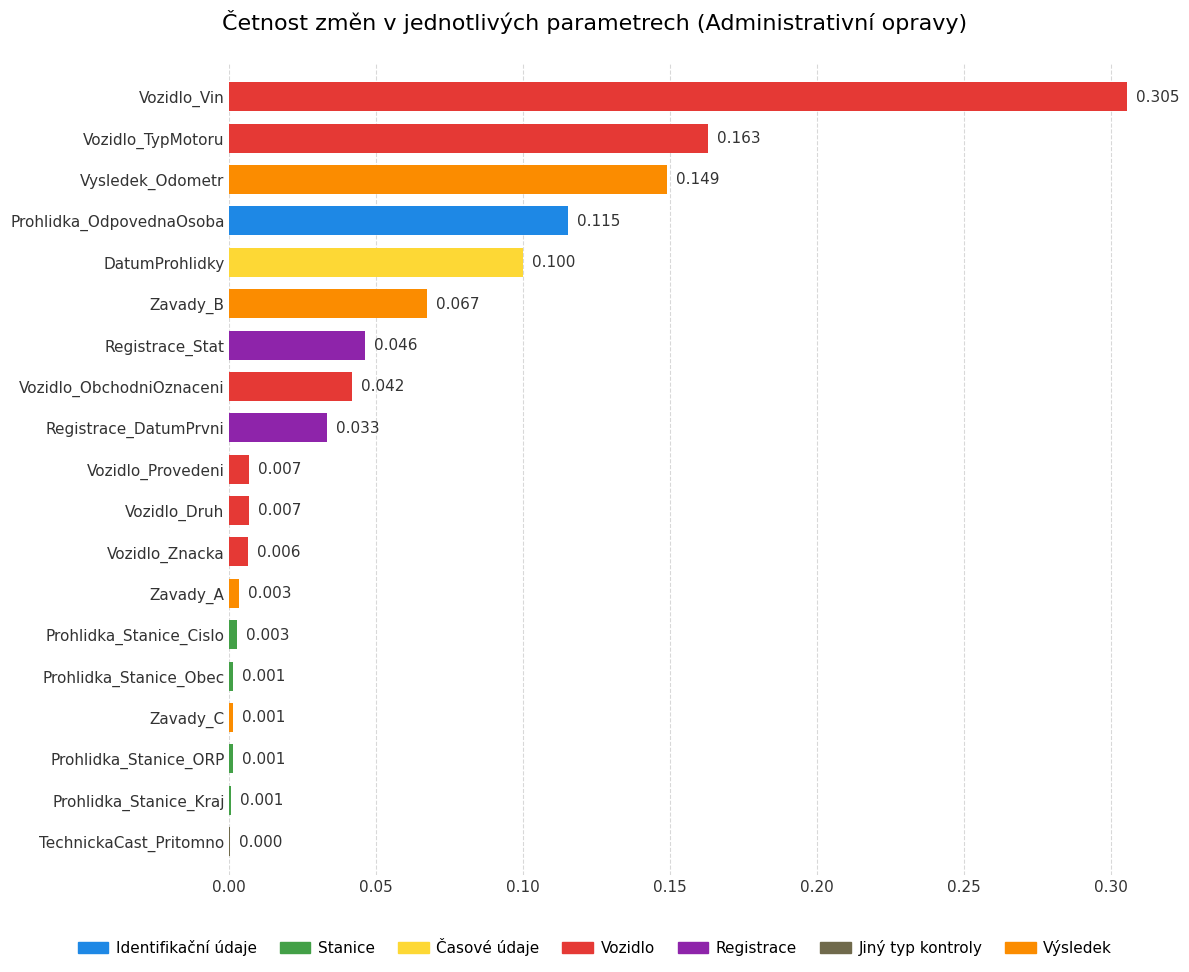

In [40]:
# Agregace počtu změn na parametr
summary = final_diff_table.group_by('Zmeneny_Parametr').len().sort('len', descending=True)

columns = summary['Zmeneny_Parametr'].to_list()
counts = summary['len'].to_list()
total_revisions = df_repairs.height
ratios = [c / total_revisions if total_revisions > 0 else 0 for c in counts]

group_indices = [group_mapping[col] for col in columns]
group_descriptions = ['Identifikační údaje', 'Stanice', 'Časové údaje', 'Vozidlo', 'Registrace', 'Emise', 'Jiný typ kontroly', 'Výsledek', 'Administrativní oprava']
horizontal_bar(columns, ratios, 'Četnost změn v jednotlivých parametrech (Administrativní opravy)', "kod/explorace/prohlidky_administrativni_opravy.svg", 3, 10, group_indices, group_descriptions)

## Zanesení administrativních oprav
Nasledujici kod funguje diky uprave na korenovy protokol

In [41]:
# Definice polí, která zůstávají v původním stavu
protected_cols = [
    'CisloProtokolu',
    'Prohlidka_Zahajeni', 
    'Prohlidka_Ukonceni', 
    'AdministrativniOprava_CisloProtokolu', 
    'AdministrativniOprava_DatumProhlidky'
]

# Sloupce určené k přepsání daty z oprav
update_cols = [c for c in df.columns if c not in protected_cols]

# Získání posledních verzí oprav pro každý protokol
latest_corrections = (
    df.filter(pl.col('AdministrativniOprava_CisloProtokolu').is_not_null())
    .sort('Prohlidka_Ukonceni')
    .group_by('AdministrativniOprava_CisloProtokolu', maintain_order=True)
    .last()
    .with_columns(pl.lit(True).alias('_has_correction'))
)

# Aplikace oprav na originální záznamy
df = (
    df.filter(pl.col('AdministrativniOprava_CisloProtokolu').is_null())
    .join(
        latest_corrections.select(
            ['AdministrativniOprava_CisloProtokolu', '_has_correction'] + 
            [pl.col(c).alias(f"{c}_Latest") for c in update_cols]
        ),
        left_on='CisloProtokolu',
        right_on='AdministrativniOprava_CisloProtokolu',
        how='left'
    )
    .with_columns([
        # Nahrazení hodnotou z opravy, pokud existuje (včetně null hodnot)
        *[
            pl.when(pl.col('_has_correction').fill_null(False))
            .then(pl.col(f"{c}_Latest"))
            .otherwise(pl.col(c))
            .alias(c)
            for c in update_cols
        ],
        # Informace o tom, zda byl zaznam opravovan
        pl.col('_has_correction').fill_null(False).alias('AdministrativneOpraveno'),
    ])
    .select([*df.columns, "AdministrativneOpraveno"]) # Vezme vše původní + nový bool
    .select(pl.exclude(['AdministrativniOprava_CisloProtokolu', 'AdministrativniOprava_DatumProhlidky']))
)

## Dataset po zanesení administrativních kontrol

In [42]:
df = df.select(['CisloProtokolu', 'DruhProhlidky', 'Prohlidka_OdpovednaOsoba', 'Prohlidka_Stanice_Cislo', 'Prohlidka_Stanice_Kraj', 'Prohlidka_Stanice_ORP', 'Prohlidka_Stanice_Obec', 'DatumProhlidky', 'Prohlidka_Zahajeni', 'Prohlidka_Ukonceni', 'Vozidlo_Vin', 'Vozidlo_Druh', 'Vozidlo_Provedeni', 'Vozidlo_Znacka', 'Vozidlo_ObchodniOznaceni', 'Vozidlo_TypMotoru', 'Registrace_DatumPrvni', 'Registrace_Stat', 'Emise_ZakladniPalivo', 'TechnickaCast_Pritomno', 'AdrCast_Pritomno', 'TskCast_Pritomno', 'Vysledek_Odometr', 'Zavady_A', 'Zavady_B', 'Zavady_C', 'AdministrativneOpraveno'])
if PRINT: schema_description(df)

,column,majority_class,majority_cnt,non_null,dtype
0,CisloProtokolu,CZ-450310-22-12-0068,1 / 15 871 603,15 871 603 / 15 871 603,String
1,DruhProhlidky,Pravidelná,15 821 449 / 15 871 603,15 871 603 / 15 871 603,String
2,Prohlidka_OdpovednaOsoba,35165,54 420 / 15 871 603,15 871 603 / 15 871 603,Int32
3,Prohlidka_Stanice_Cislo,540514,248 743 / 15 871 603,15 871 603 / 15 871 603,Int32
4,Prohlidka_Stanice_Kraj,Středočeský kraj,2 294 548 / 15 871 603,15 871 603 / 15 871 603,String
5,Prohlidka_Stanice_ORP,Hlavní město Praha,1 646 835 / 15 871 603,15 871 603 / 15 871 603,String
6,Prohlidka_Stanice_Obec,Praha,1 646 835 / 15 871 603,15 871 603 / 15 871 603,String
7,DatumProhlidky,2025-05-12,14 747 / 15 871 603,15 871 603 / 15 871 603,Date
8,Prohlidka_Zahajeni,2025-11-03 08:37:33.283000,7 / 15 871 603,15 871 603 / 15 871 603,"Datetime(time_unit='us', time_zone=None)"
9,Prohlidka_Ukonceni,2019-04-11 10:15:00,6 / 15 871 603,15 871 603 / 15 871 603,"Datetime(time_unit='us', time_zone=None)"


### Ulozeni mezivysledku

In [105]:
df.write_parquet(r"E:\CVUT_BAP\kod\data\processed\prohlidky.parquet")

# Chybějící hodnoty

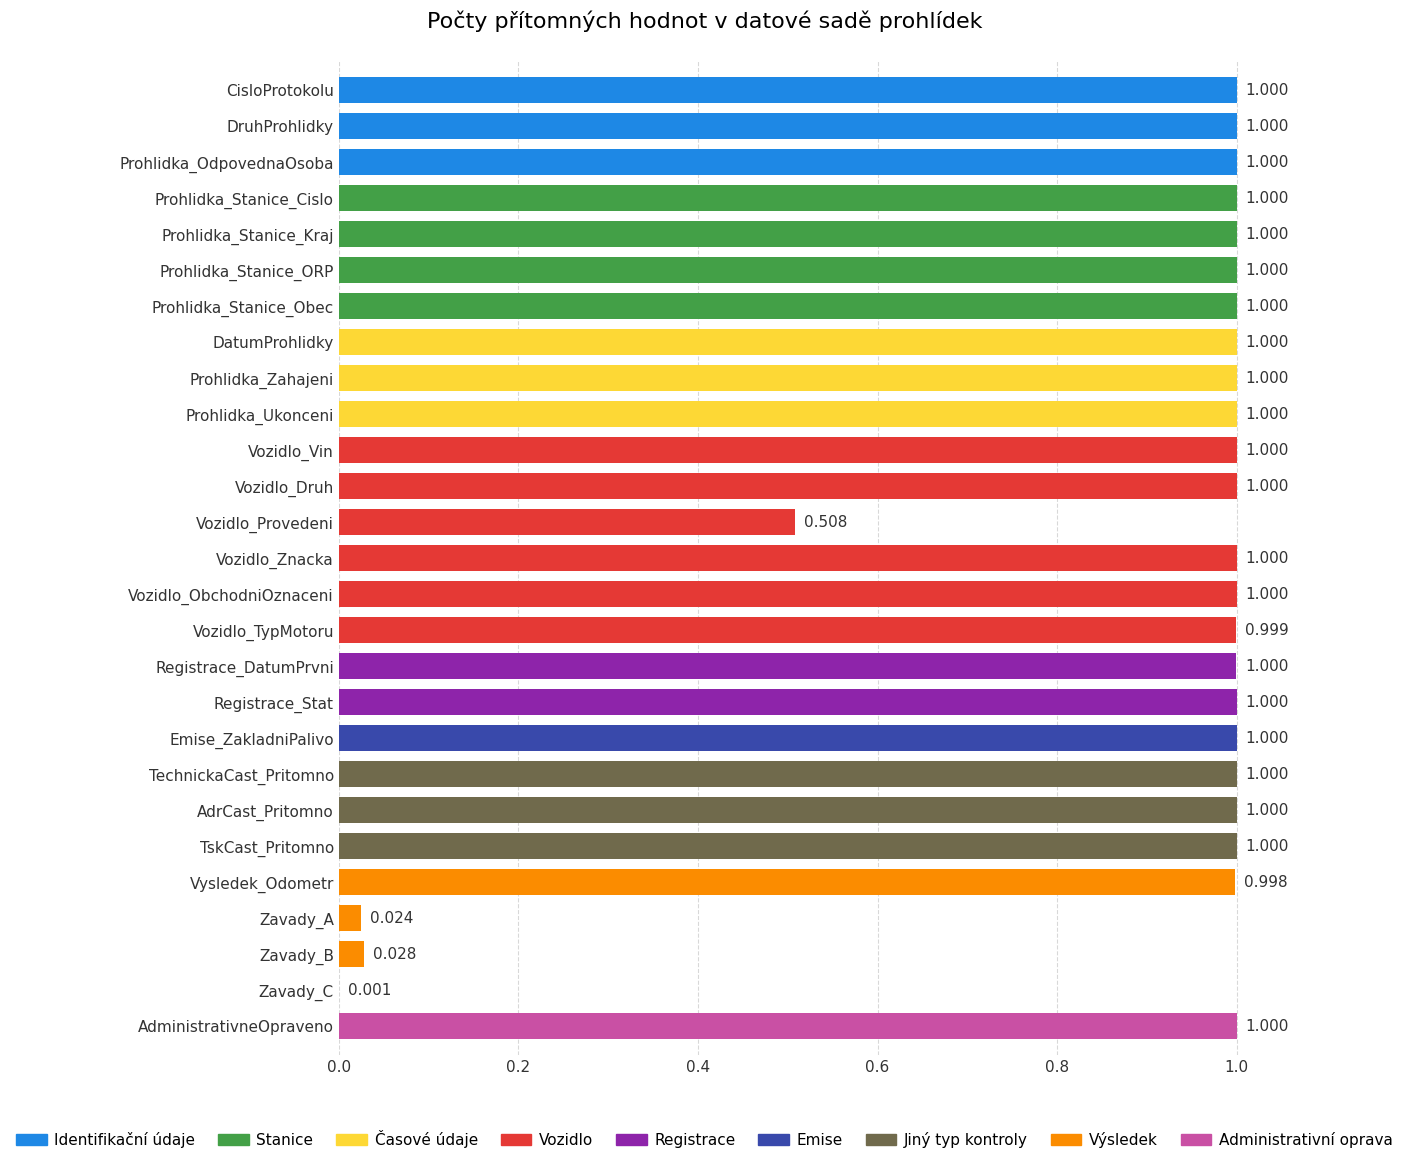

In [184]:
# Výpočet metrik
total_rows = len(df)
columns = df.columns
null_counts = df.null_count().row(0)
non_null_counts = [total_rows - count for count in null_counts]
ratios = [count / total_rows if total_rows > 0 else 0 for count in non_null_counts]

group_mapping['AdministrativneOpraveno'] = 8
group_indices = [group_mapping[col] for col in columns]

group_descriptions = ['Identifikační údaje', 'Stanice', 'Časové údaje', 'Vozidlo', 'Registrace', 'Emise', 'Jiný typ kontroly', 'Výsledek', 'Administrativní oprava']
horizontal_bar(
    labels=columns, 
    counts=ratios, 
    title='Počty přítomných hodnot v datové sadě prohlídek', 
    save_path='kod/explorace/prohlidky_pritomne_hodnoty.svg', 
    decimals=3, 
    height=12, 
    group_indices=group_indices, 
    group_descriptions=group_descriptions
)

# Analýza jednotlivých příznaků
## Druh prohlídky

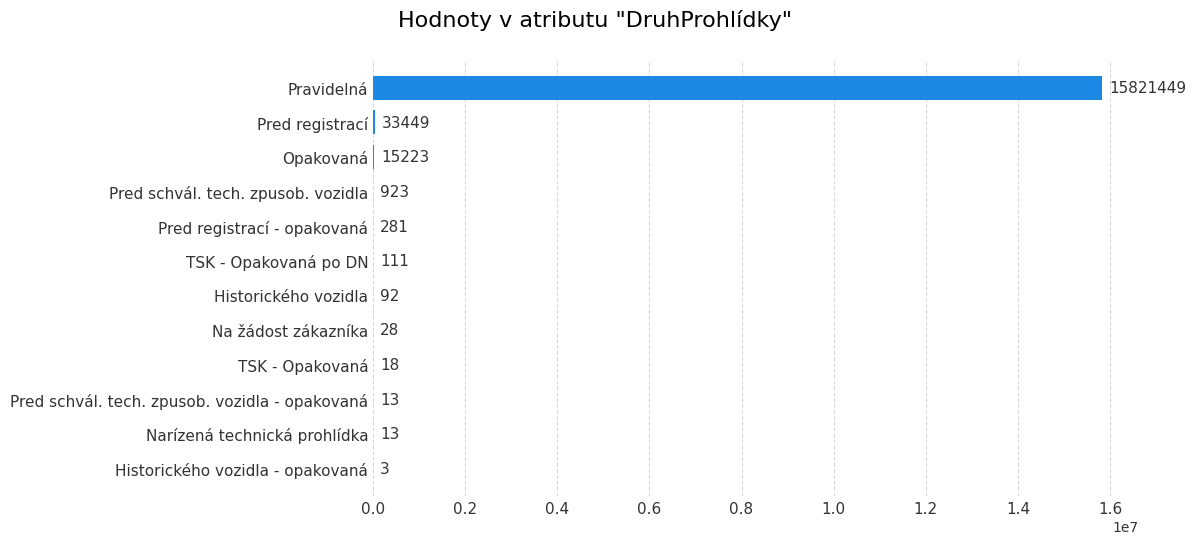

Podíl opakovaných prohlídek na všech 0.09591343735097205 %


In [64]:
if PRINT:
    exam_types = df['DruhProhlidky'].value_counts().sort(by='count', descending=True)
    horizontal_bar(exam_types['DruhProhlidky'], exam_types['count'], 'Hodnoty v atributu "DruhProhlídky"', 'kod/explorace/prohlidky_druh_prohlidky.svg')
    print(f'Podíl opakovaných prohlídek na všech {exam_types.filter(pl.col('DruhProhlidky') == 'Opakovaná')['count'].item() / exam_types['count'].sum() * 100} %')

## Prohlidka odpovedna osoba

In [76]:
print(df['Prohlidka_OdpovednaOsoba'].n_unique())
df.group_by("Prohlidka_OdpovednaOsoba").agg(pl.col("Prohlidka_Stanice_Cislo").n_unique().alias('PocetStanic')).filter(pl.col('PocetStanic') > 1).sort(by='PocetStanic', descending=True)

4152


Prohlidka_OdpovednaOsoba,PocetStanic
i32,u32
103707,8
54093,6
56103,6
61407,5
40795,5
…,…
8649,2
14761,2
25033,2


## Prohlidka stanice cislo

In [111]:
provozovatel_mapping = pl.read_parquet(r"E:\CVUT_BAP\kod\data\processed\stanice.parquet")
provozovatel_mapping

Stanice_Cislo,Provozovatel_Nazev
str,str
"""110301""","""Emitech s.r.o."""
"""110302""","""E2F2 s.r.o."""
"""110401""","""Tomáš Krejčí"""
"""110501""","""Daimler Truck Česká republika …"
"""110502""","""Autosprint Stodůlky s.r.o."""
…,…
"""6745""","""DS BYT s.r.o."""
"""6801""","""K - traktor, s.r.o."""
"""6813""","""Pro-Truck servis Olomouc s.r.o…"


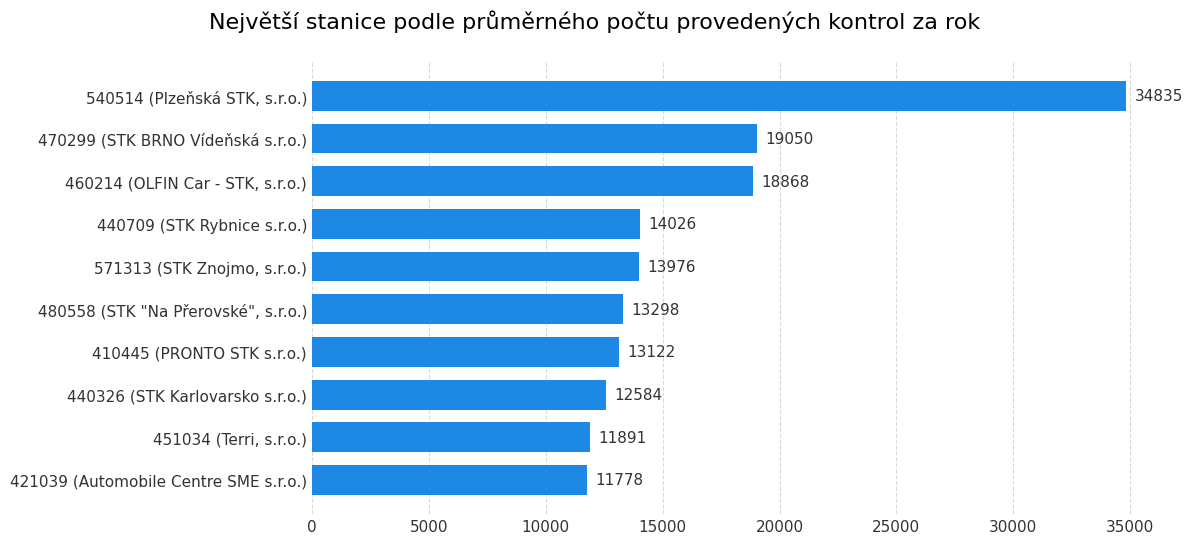

In [119]:
# Pomocne informace
timeframe = df.select(diff_years = (pl.col("DatumProhlidky").max() - pl.col("DatumProhlidky").min()).dt.total_days() / 365.24).item()
provozovatel_mapping = pl.read_parquet(r"E:\CVUT_BAP\kod\data\processed\stanice.parquet")

# Samotne nalezeni top stanic
top_stanice = df['Prohlidka_Stanice_Cislo'].value_counts().sort(by='count', descending=True).head(10)

labels = top_stanice.select(pl.col('Prohlidka_Stanice_Cislo').cast(pl.String)).join(provozovatel_mapping, how='left', left_on='Prohlidka_Stanice_Cislo', right_on='Stanice_Cislo').select(merged = pl.col("Prohlidka_Stanice_Cislo") + " (" + pl.col("Provozovatel_Nazev") + ")")['merged'].to_list()
counts = (top_stanice['count'] / timeframe).to_list()
title = f'Největší stanice podle průměrného počtu provedených kontrol za rok'
path = 'kod/explorace/prohlidky_top_stanice.svg'

horizontal_bar(labels, counts, title, path)


## Prohlidka stanice kraj

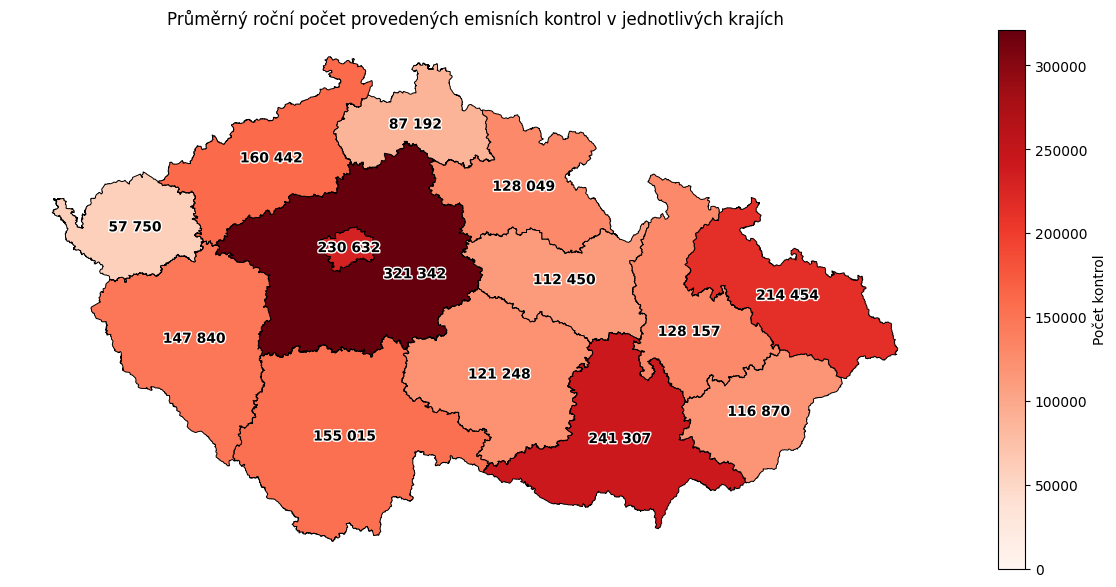

In [ ]:
# Definice převodníku
kraje_mapping = {
    "Hlavní město Praha": "CZ0100000000",
    "Středočeský kraj": "CZ0200000000",
    "Jihočeský kraj": "CZ0310000000",
    "Plzeňský kraj": "CZ0320000000",
    "Karlovarský kraj": "CZ0410000000",
    "Ústecký kraj": "CZ0420000000",
    "Liberecký kraj": "CZ0510000000",
    "Královéhradecký kraj": "CZ0520000000",
    "Pardubický kraj": "CZ0530000000",
    "Kraj Vysočina": "CZ0630000000",
    "Jihomoravský kraj": "CZ0640000000",
    "Olomoucký kraj": "CZ0710000000",
    "Zlínský kraj": "CZ0720000000",
    "Moravskoslezský kraj": "CZ0800000000"
}

# Agregace v Polars
counts_pl = df.with_columns(pl.col("Prohlidka_Stanice_Kraj").replace(kraje_mapping).alias("kod_kraje")).group_by("kod_kraje").agg((pl.len() / timeframe).alias("pocet"))

plot_czech_regional_map(counts_pl=counts_pl, value_column="pocet", title='Průměrný roční počet provedených emisních kontrol v jednotlivých krajích', legend_label="Počet kontrol", output_path="kod/explorace/prohlidky_pocty_mapa.svg")

## Datum prohlidky

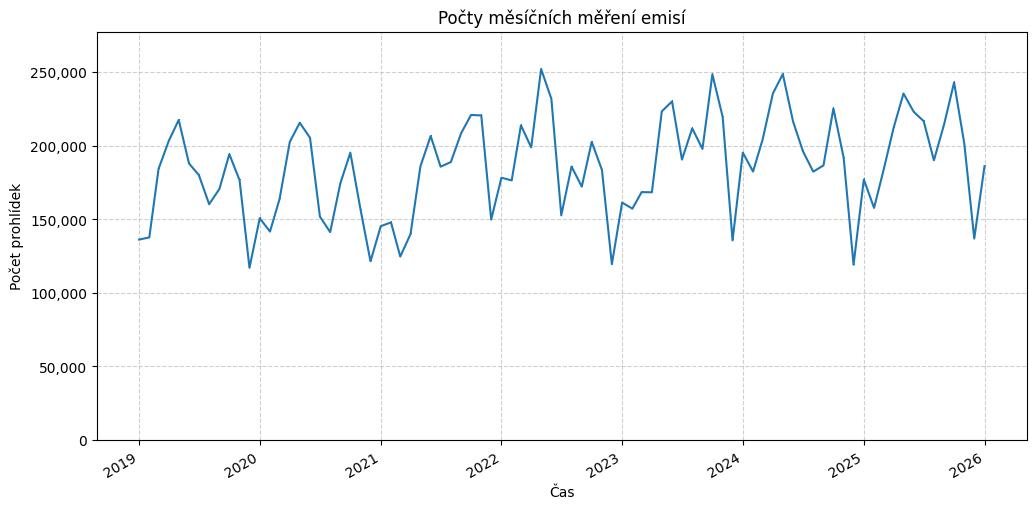

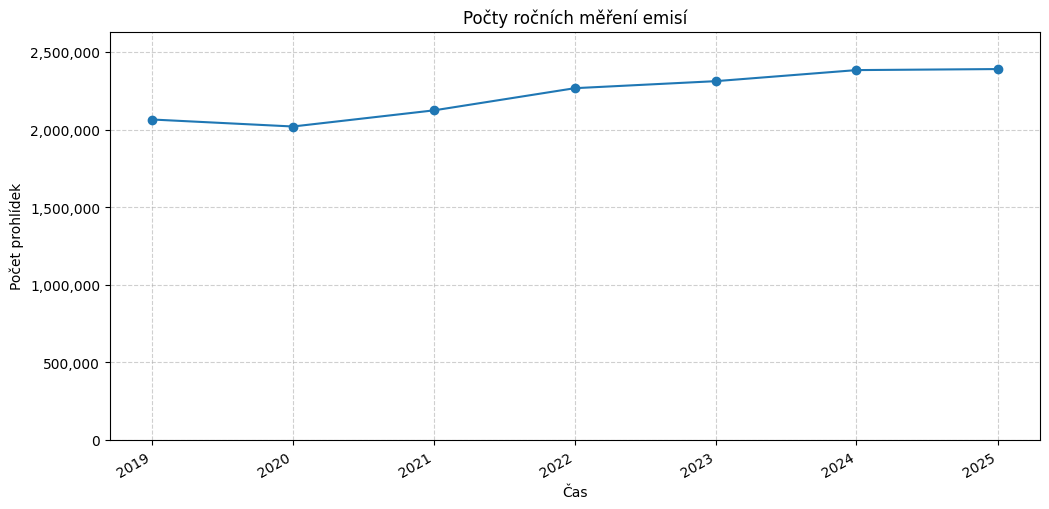

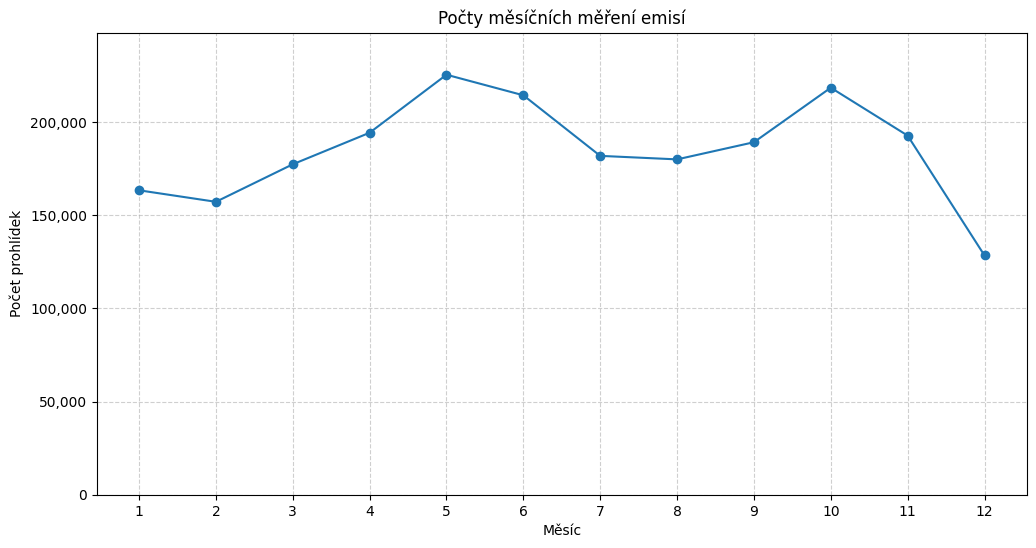

In [ ]:
time_series_all(df['DatumProhlidky'], 'Počty měsíčních měření emisí', 'Počet prohlídek', '1mo')
time_series_all(df['DatumProhlidky'], 'Počty ročních měření emisí', 'Počet prohlídek', '1y')
time_series_year(df['DatumProhlidky'], 'Průměrné počty měsíčních měření emisí', 'Počet prohlídek')

## Prohlidka zahajeni

## Prohlidka delka

## Vozidlo VIN

## Vozidlo druh

## Vozidlo provedeni

## Vozidlo znacka

## Vozidlo obchodni oznaceni

## Vozidlo typ motoru

In [79]:
df['Vozidlo_TypMotoru']

Vozidlo_TypMotoru
str
"""Z10XE"""
"""BXW"""
"""4G63"""
"""654"""
"""CBZA"""
…
"""G4ED"""
"""DGT"""
"""HFX"""


## Registrace datum prvni

## Registrace stat

## Emise zakladni palivo

## Technicka cast pritomno

## ADR cast pritomno

## TSK cast pritomno

## Vysledek odometr

## Technicka cast pritomno

## Zavady A

## Zavady B

## Zavady C

## Administrativne opraveno